In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

data1 = pd.read_csv("RAVE_DR6SC_GaiaeDR3_SHdist_orbitsAGAMA.csv", low_memory=False)

data = Table.read("xyz ML.csv") 

data = data.filled()
energy = data["Energy"]
jr = data["Jr"]
jphi = data["Jphi"]
jz = data["Jz"]

ecc = data1["e_1"]

FileNotFoundError: [Errno 2] No such file or directory: 'xyz ML.csv'

In [7]:
dist_err = (data1['dist84_2'] - data1['dist16_2'])/2

data1.loc[:, 'dist_err'] = dist_err



In [9]:


# Load the CSV file


# Separate the features (X) and the target variable (y)

X = data1[['x','y','z','u_2','v_2','w_2']]
y = data1[['E_2','Jr_2','Jz_2','Jphi']]

# Discretize the continuous target into bins (e.g., low, medium, high energy)
#y = pd.cut(y, bins=3, labels=[0, 1, 2])  # Adjust the bins and labels as needed

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train['x'] = pd.to_numeric(X_train['x'], errors='coerce')
# Initialize and train the regression model
#regressor = (RandomForestRegressor(n_estimators=100, random_state=42))
regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)



KeyboardInterrupt



In [12]:
# Select the features from the real dataset
data1['x'] = pd.to_numeric(data1['x'], errors='coerce')

X_real = data1[['x','y','z','u_2','v_2','w_2']]

# Predict the energy class
real_energy_predictions = regressor.predict(X_real)

# Add predictions to the real dataset
#real_data['Predicted_Energy'] = real_energy_predictions




In [14]:
a=data1['Jphi']
b=a[a<0]
len(b)

105972

In [16]:
pd.DataFrame(real_energy_predictions).to_csv('xyz ML.csv')

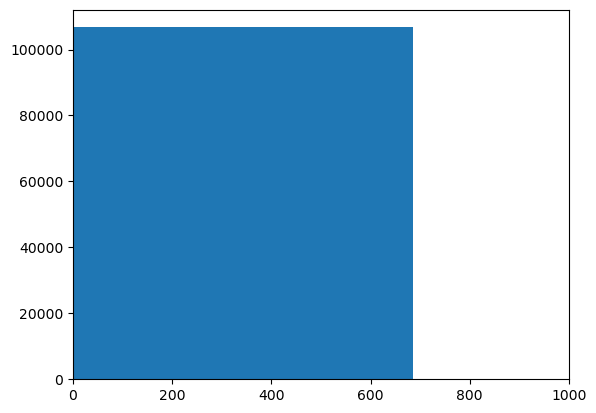

In [17]:
delta_Jphi = pd.to_numeric(jphi) - data1['Jphi']

# Calculate the percentage difference
per_Jphi = (delta_Jphi/ pd.to_numeric(jphi)) * 100

plt.hist(per_Jphi)
plt.xlim(0,1000)
plt.show()



In [20]:
# remove error


data1['per_Jphi'] = per_Jphi
data2 = data1[data1['per_Jphi'] <= 20]



# Load the CSV file


# Separate the features (X) and the target variable (y)

X = data2[['x','y','z','u_2','v_2','w_2']]
y = data2[['E_2','Jr_2','Jz_2','Jphi']]

# Discretize the continuous target into bins (e.g., low, medium, high energy)
#y = pd.cut(y, bins=3, labels=[0, 1, 2])  # Adjust the bins and labels as needed

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train['x'] = pd.to_numeric(X_train['x'], errors='coerce')
# Initialize and train the regression model
#regressor = (RandomForestRegressor(n_estimators=100, random_state=42))
regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)



KeyboardInterrupt



In [ ]:
import math
a=math.sqrt(mse)
a

In [ ]:
per_Jphi.min()

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3409/596579998.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')


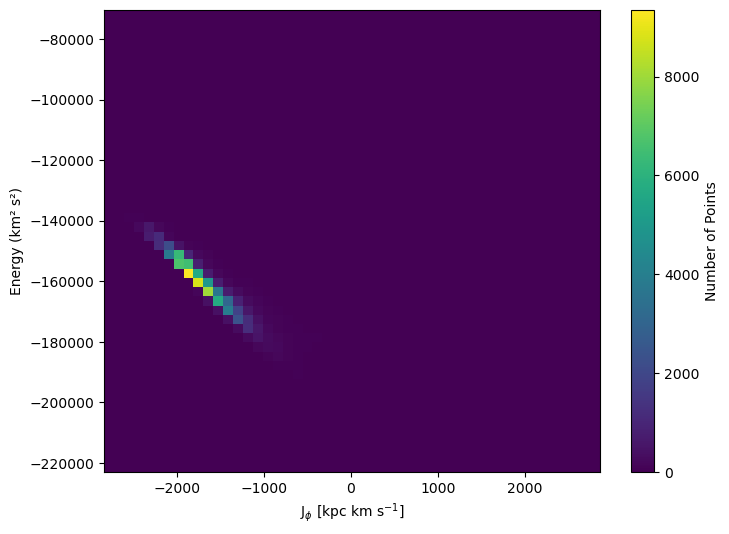

In [26]:
x = data1['Jphi']
y = data1['E_2']

# Plot a 2D histogram (heatmap)
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=50, cmap='viridis')

# Add color bar for reference
plt.colorbar(label='Number of Points')

# Labels and title
plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')
plt.ylabel('Energy (km² s²)')


# Show the plot
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3409/1996035700.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')


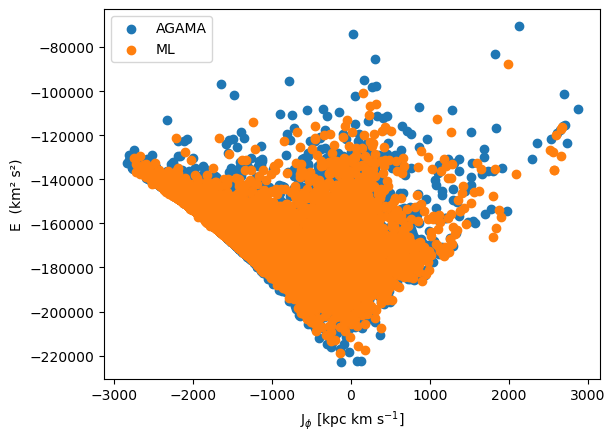

In [32]:
E = pd.read_csv("xyz ML.csv", low_memory=False)
Lz = pd.read_csv("Energy and Lxz both.csv", low_memory=False)


E2 = data1['E_2']
Lz2 = data1['Jphi']
plt.scatter(Lz2,E2,label='AGAMA')
plt.scatter(jphi,energy,label='ML')
plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')
plt.ylabel('E  (km² s²)')
plt.legend()
#plt.savefig("EnergyML.jpeg",dpi=300)

plt.show()

In [34]:
x = jphi
y = energy

# Plot a 2D histogram (heatmap)
plt.figure(figsize=(8, 6))
plt.hist2d(data['Jphi'][highlight_mask], E['Energy'][highlight_mask], bins=50, cmap='viridis')

# Add color bar for reference
plt.colorbar(label='Number of Points')

# Labels and title
plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')
plt.ylabel('Energy (km² s²)')


# Show the plot
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3409/479219368.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')
/tmp/ipykernel_3409/479219368.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')


NameError: name 'highlight_mask' is not defined

<Figure size 800x600 with 0 Axes>

In [35]:
c2=per_Jphi[(per_Jphi < -20) | (per_Jphi > 20)]
len(E['Jphi'])

106900

<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_9765/933089055.py:36: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')


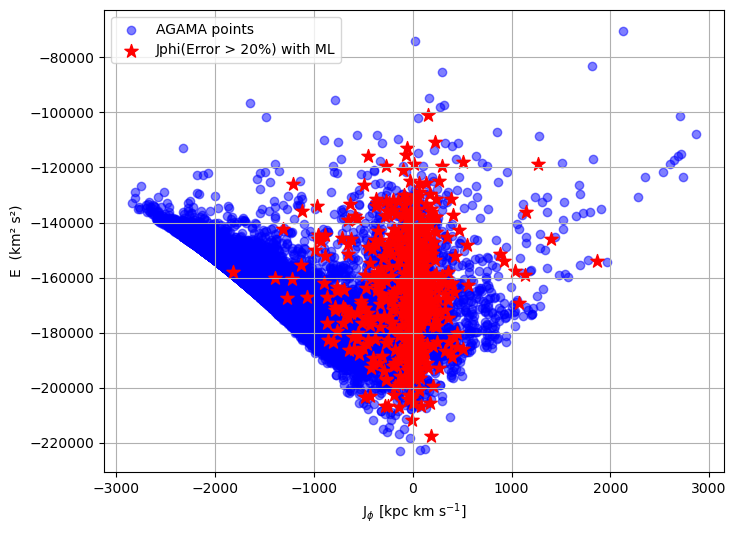

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
E = pd.read_csv("xyz ML.csv", low_memory=False)

# Assuming `per_Jphi` is already calculated; if not, define it
# For example: per_Jphi = (E['Jphi_error'] / E['Jphi']) * 100

# Define the condition for highlighting
highlight_mask = (per_Jphi < -20) | (per_Jphi > 20)  # Highlight errors > 20% or < -20%

# Plot the scatter plot
plt.figure(figsize=(8, 6))

# Plot all points with a base color (e.g., blue)
plt.scatter(
    data1['Jphi'], 
    data1['E_2'], 
    c='blue', 
    alpha=0.5, 
    label='AGAMA points'
)

# Plot points that meet the condition with red stars
plt.scatter(
    E['Jphi'][highlight_mask],  # Points satisfying the condition
    E['Energy'][highlight_mask],  # Points satisfying the condition
    c='red', 
    marker='*', 
    s=100,  # Size of the stars
    label='Jphi(Error > 20%) with ML'
)

# Add labels, legend, and grid
plt.xlabel('J$_\phi$ [kpc km s$^{-1}$]')
plt.ylabel('E  (km² s²)')
plt.legend()
plt.grid(True)
#plt.savefig("error 20%.jpeg",dpi=500)
# Show the plot
plt.show()


# Clustring

In [3]:
import hdbscan
import numpy as np
import matplotlib.pyplot as plt
import time
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import matplotlib.lines as mlines
import matplotlib.cm as cm
from sklearn import preprocessing
import pylab as pl
import os
from matplotlib import pyplot
import pandas as pd
#%matplotlib inline

from astropy.stats import biweight_scale
from astropy.stats import biweight_location
import seaborn as sns
import plotly.graph_objects as go

import random
random.seed(999)

from random import shuffle
from random import randrange
from random import  uniform
from astropy.table import Table

In [98]:
data = Table.read("xyz ML.csv") 

data = data.filled()
energy = data["Energy"]
jr = data["Jr"]
jphi = data["Jphi"]
jz = data["Jz"]

ecc = data1["e_1"]

In [23]:
# IMPORTANT: here I am normalizing via biweight scale/loocation, but in LIMBERG+2021 we used the preprocessing task from sklearn 

# stack the results for computation
X_init = np.vstack([energy, jr, jphi, jz]).T 

loc_energy = biweight_location(energy)
scale_energy = biweight_scale(energy)

loc_jr = biweight_location(jr)
scale_jr = biweight_scale(jr)

loc_jphi = biweight_location(jphi)
scale_jphi = biweight_scale(jphi)

loc_jz = biweight_location(jz)
scale_jz = biweight_scale(jz)

norm_energy = []
norm_jr     = []
norm_jphi   = []
norm_jz     = []

for i in range(len(energy)):
    norm_energy.append( (energy[i] - loc_energy)/scale_energy )
    norm_jr.append( (jr[i] - loc_jr)/scale_jr )
    norm_jphi.append( (jphi[i] - loc_jphi)/scale_jphi )
    norm_jz.append( (jz[i] - loc_jz)/scale_jz )

X = np.vstack([norm_energy, norm_jr, norm_jz, norm_jphi]).T

In [25]:
data=np.array([energy,jr,jz,jphi])
Data=data.T

In [27]:
method = 'leaf'
epsilon = 0.0

clusterer = hdbscan.HDBSCAN(
        min_cluster_size=int(3),
        min_samples=int(5),
        prediction_data=True,
        cluster_selection_method=method,
        cluster_selection_epsilon=epsilon
    )

clusterer.fit(Data)
label1 = clusterer.labels_

    #nmax = data.shape[0]
#occur = np.bincount(label1[label1 >= 0])
#avg = round(np.mean(occur), 2)




In [28]:
nmax=clusterer.labels_.max()
nmax

3913

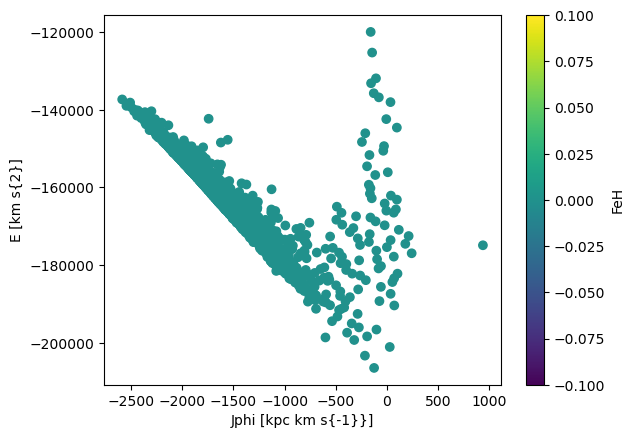

In [31]:
Enem = np.zeros(nmax)
Jphim = np.zeros(nmax)
Jzm = np.zeros(nmax)
Jrm = np.zeros(nmax)
color = np.zeros(nmax)
probm = np.zeros(nmax)
Rminm = np.zeros(nmax)
Rmaxm = np.zeros(nmax)
Zmaxm = np.zeros(nmax)
eccm = np.zeros(nmax)
labelm = np.zeros(nmax)

##############################################
# Plot centroids of each cluster#clusterer.labels_.max()) with prob>0.8
##############################################

for i in range(0,nmax):
    #color[i]=i
    Enem[i]=np.mean(data[0][clusterer.labels_==i])
    Jphim[i]=np.mean(data[3][clusterer.labels_==i])
    Jrm[i]=np.mean(data[1][clusterer.labels_==i])
    Jzm[i]=np.mean(data[2][clusterer.labels_==i])
    probm[i]=np.mean(clusterer.probabilities_[clusterer.labels_==i])
    eccm[i]=np.mean(ecc[clusterer.labels_==i])
    labelm[i]=i

plt.scatter(Jphim,Enem,c=color)
plt.xlabel('Jphi [kpc km s{-1}}]')
plt.ylabel('E [km s{2}]')
cbar = plt.colorbar()
cbar.solids.set_edgecolor("face")
cbar.set_label('FeH')
plt.show()

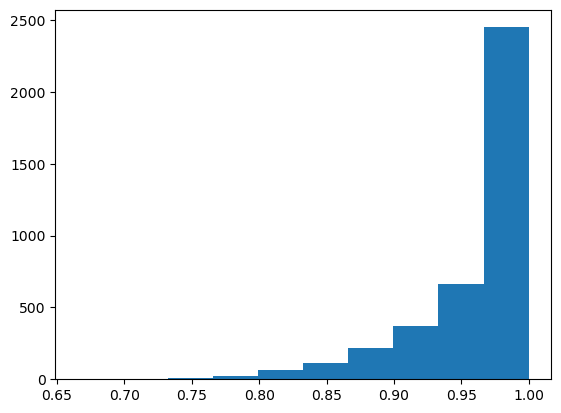

In [33]:
plt.hist(probm)
plt.show()

In [35]:
nmax2=nmax
labels_cl=clusterer.labels_

In [37]:
##################################################
# consider target with probability > 0.8
# check how they classify following literature
#  labelSUB = label substructure
#  GSE = 1
#  Helmi = 2
#  Sequoia = 3
#  Rg5 = 4
#  Thamnos = 5
#  Splashed Disk = 6
#  MWTD = 7
#  NC = 0
#####################################################
labelSUB= np.zeros(nmax)
labelseq = np.zeros(len(energy))
#GSE - Yuan  e>0.7, Jr> 500, Jz<500 
for i in range (0,nmax):
    if (eccm[i] > 0.69) and (Jrm[i] > 500) and (Jzm[i] < 500) and (Jphim[i] < 350) and (Jphim[i] > -200):
        labelSUB[i] = 1
    else:
        labelSUB[i]= labelSUB[i]

#MWTD
for i in range (0,nmax):
    if (Jrm[i] < 290) and (Jrm[i] > 120) and (Jzm[i] < 210) and (Jzm[i] > 35) and (Jphim[i] > -1100) and (Jphim[i] < -650):
        labelSUB[i] = 3
    else:
        labelSUB[i]= labelSUB[i]
        
#Splashed
for i in range (0,nmax):
    if (Jrm[i] < 90) and (Jrm[i] > 20) and (Jzm[i] < 115) and (Jzm[i] > 20) and (Jphim[i] < -1280) and (Jphim[i] > -1420):
        labelSUB[i] = 2
    else:
        labelSUB[i]= labelSUB[i]
#Sequoia
for i in range (0,nmax):
    if (Jphim[i] > 2000) and (Enem[i] > -130000):
        labelSUB[i] = 4
    else:
        labelSUB[i]=labelSUB[i]
        
#Thamnos(E6[i]<-160000) & (Jz6[i]>500) & (Jz6[i]<1900) & (Jr6[i]<500)
for i in range(nmax):
    if (Jrm[i] < 90) and (Jrm[i] > 20) and (Jzm[i] < 115) and (Jzm[i] > 20) and (Jphim[i] < -1280) and (Jphim[i] > -1420):
        labelSUB[i] = 6
for i in range (0,nmax):
#    if  (Jzm[i] > 100) and (Jzm[i] < 1900 and (Jrm[i]<500)):
    if (Jphim[i] > 380) :
        labelSUB[i] = 5
    else:
        labelSUB[i]= labelSUB[i]
        
        
labelSUB

array([1., 1., 0., ..., 0., 0., 0.])

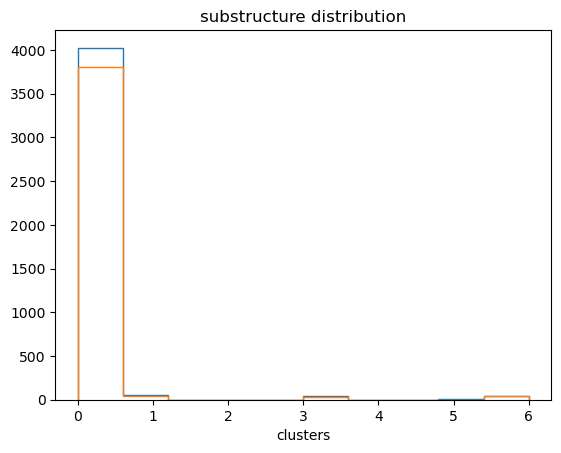

In [69]:
labelSUB1=pd.read_csv("labelSUB.csv")['0']
plt.hist(labelSUB1,histtype='step')
plt.hist(labelSUB,histtype='step')
plt.xlabel("clusters")
plt.title("substructure distribution")
plt.savefig("substructure distribution.jpeg",dpi=300)

plt.show()

In [62]:
labels_cl=clusterer.labels_
GSElabels = np.where(labelSUB == 1)[0]
SPLASHlabels = np.where(labelSUB == 2)[0]  # Indices of stars classified as Splashed Disk
MWTDlabels = np.where(labelSUB == 3)[0]  # Indices of stars classified as MWTD
SEQUOIAlabels = np.where(labelSUB==4)[0]

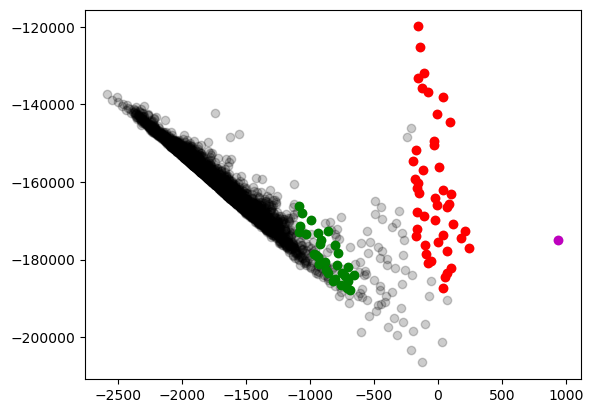

In [162]:
plt.scatter(Jphim,Enem, c='k', alpha=0.2)
#plt.scatter(data[3][106902:106942],data[0][106902:106942],label='K2 stars', c = 'blue', marker = '*',s=70)
plt.scatter(Jphim[(labelSUB==1)],Enem[(labelSUB==1)],c='r') #GSE
plt.scatter(Jphim[(labelSUB==3)],Enem[(labelSUB==3)],c='g') #MWTD
plt.scatter(Jphim[(labecc = data1["e_1"]elSUB==2)],Enem[(labelSUB==2)],c='c') #Helmi
plt.scatter(Jphim[(labelSUB==5)],Enem[(labelSUB==5)],c='m') #Thamnos
plt.show()

In [75]:
import pandas as pd

# Initialize empty lists to collect data
gseid = []
gseprob = []

# Iterate over each GSE label
for i in range(len(SEQUOIAlabels)):
    # Collect IDs and probabilities for the current GSE label
    ids = data[6][(labels_cl == SEQUOIAlabels[i])]
    probs = clusterer.probabilities_[(labels_cl == SEQUOIAlabels[i])]
    # Extend the lists with new data
    gseid.extend(ids)
    gseprob.extend(probs)

# Create a DataFrame from the collected data
df = pd.DataFrame({
    'source_ID': gseid,
    'Prob': gseprob
})

# Print DataFrame to verify content
print("DataFrame content before saving:")
print(df)

# Save the DataFrame to a CSV file
df.to_csv('sequia_data.csv', index=False)


DataFrame content before saving:
Empty DataFrame
Columns: [source_ID, Prob]
Index: []


<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_20065/3144304981.py:48: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_xlabel('J$_\phi$ [kpc km s$^{-1}$]', fontsize=fontsize_labels)


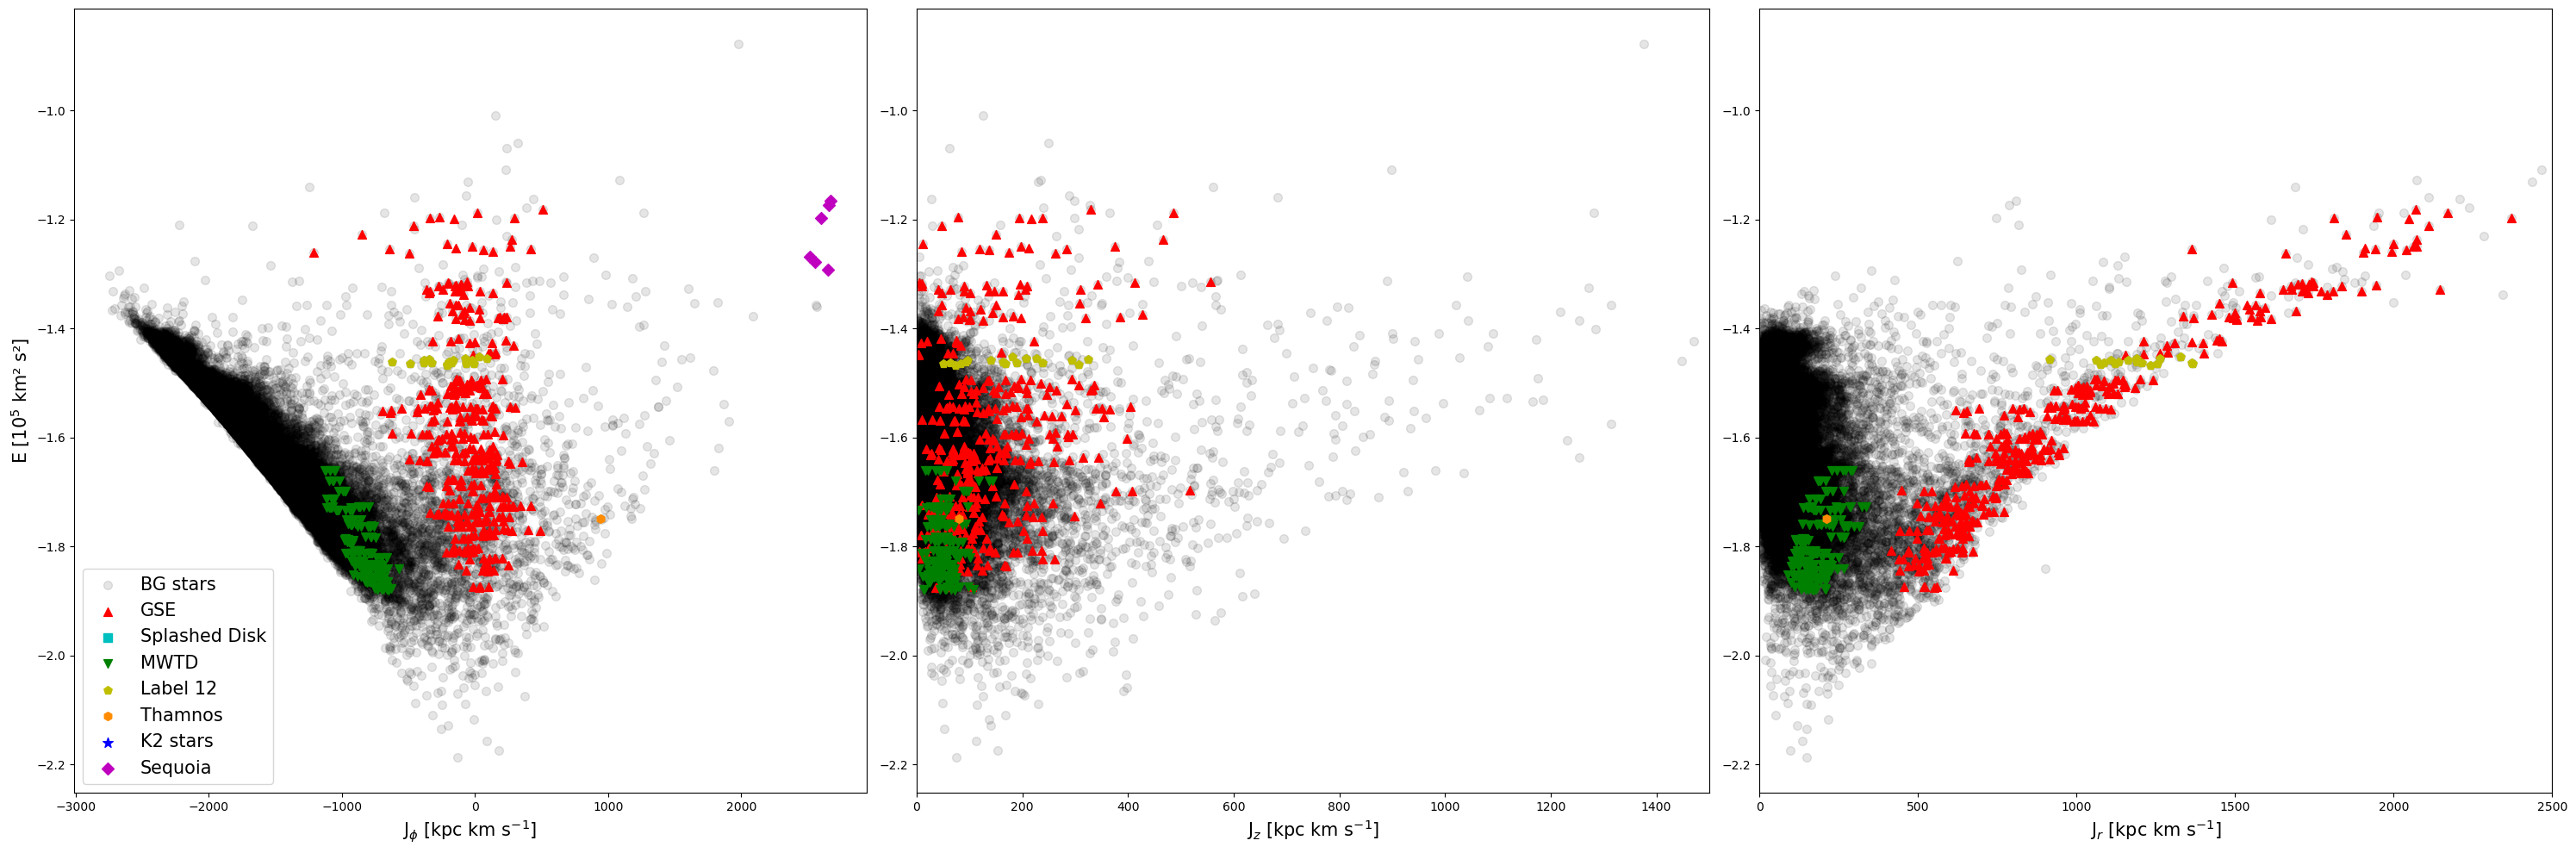

In [66]:
import matplotlib.pyplot as plt

# Set plot aesthetics
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

# Adjust figure size and scaling
fig, axs = plt.subplots(1, 3, figsize=(30, 10))  # 1 row, 3 columns

# Shared settings for labels and fonts
fontsize_labels = 15  # Increased label font size
marker_size = 50  # Adjusted marker size

# Plot 1: Jphi vs Energy
ax1 = axs[0]
ax1.scatter(jphi, energy / 100000, s=marker_size, c='k', alpha=0.1, marker='o', label='BG stars')

for i in range(len(GSElabels)):
    ax1.scatter(data[3][(labels_cl == GSElabels[i])], 
                data[0][(labels_cl == GSElabels[i])] / 100000, s=marker_size, c='r', marker='^')
ax1.scatter(Jphim[(labelSUB == 1)], Enem[(labelSUB == 1)] / 100000, 
            s=marker_size, c='r', marker='^', label='GSE')

for i in range(len(SPLASHlabels)):
    ax1.scatter(data[3][(labels_cl == SPLASHlabels[i])], 
                data[0][(labels_cl == SPLASHlabels[i])] / 100000, s=marker_size, c='c', marker='s')
ax1.scatter(Jphim[(labelSUB == 2)], Enem[(labelSUB == 2)] / 100000, 
            s=marker_size, c='c', marker='s', label='Splashed Disk')

for i in range(len(MWTDlabels)):
    ax1.scatter(data[3][(labels_cl == MWTDlabels[i])], 
                data[0][(labels_cl == MWTDlabels[i])] / 100000, s=marker_size, c='g', marker='v')
ax1.scatter(Jphim[(labelSUB == 3)], Enem[(labelSUB == 3)] / 100000, 
            s=marker_size, c='g', marker='v', label='MWTD')

ax1.scatter(data[3][(labels_cl == 12)], data[0][(labels_cl == 12)] / 100000, s=marker_size, c='y', marker='p', label='Label 12')
ax1.scatter(Jphim[(labelSUB == 5)], Enem[(labelSUB == 5)] / 100000, 
            s=marker_size, c='darkorange', marker='h', label='Thamnos')
ax1.scatter(data[3][106902:106942], data[0][106902:106942] / 10**5, 
            label='K2 stars', c='blue', marker='*', s=marker_size * 1.5)
ax1.scatter(data[3][(data[0] > -130000) & (data[3] > 2000)], 
            data[0][(data[0] > -130000) & (data[3] > 2000)] / 100000, 
            s=marker_size, c='m', marker='D', label='Sequoia')

ax1.legend(fontsize=fontsize_labels)  # Show legend only for the first graph
ax1.set_xlabel('J$_\phi$ [kpc km s$^{-1}$]', fontsize=fontsize_labels)
ax1.set_ylabel('E [10$^5$ km² s²]', fontsize=fontsize_labels)

# Plot 2: Jz vs Energy
ax2 = axs[1]
ax2.scatter(jz, energy / 100000, s=marker_size, c='k', alpha=0.1, marker='o')

for i in range(len(GSElabels)):
    ax2.scatter(data[2][(labels_cl == GSElabels[i])], 
                data[0][(labels_cl == GSElabels[i])] / 100000, s=marker_size, c='r', marker='^')
ax2.scatter(Jzm[(labelSUB == 1)], Enem[(labelSUB == 1)] / 100000, s=marker_size, c='r', marker='^')

for i in range(len(SPLASHlabels)):
    ax2.scatter(data[2][(labels_cl == SPLASHlabels[i])], 
                data[0][(labels_cl == SPLASHlabels[i])] / 100000, s=marker_size, c='c', marker='s')
ax2.scatter(Jzm[(labelSUB == 2)], Enem[(labelSUB == 2)] / 100000, s=marker_size, c='c', marker='s')

for i in range(len(MWTDlabels)):
    ax2.scatter(data[2][(labels_cl == MWTDlabels[i])], 
                data[0][(labels_cl == MWTDlabels[i])] / 100000, s=marker_size, c='g', marker='v')
ax2.scatter(Jzm[(labelSUB == 3)], Enem[(labelSUB == 3)] / 100000, s=marker_size, c='g', marker='v')

ax2.scatter(data[2][(labels_cl == 12)], data[0][(labels_cl == 12)] / 100000, s=marker_size, c='y', marker='p')
ax2.scatter(Jzm[(labelSUB == 5)], Enem[(labelSUB == 5)] / 100000, s=marker_size, c='darkorange', marker='h')
ax2.scatter(data[2][106902:106942], data[0][106902:106942] / 10**5, 
            c='blue', marker='*', s=marker_size * 1.5)

ax2.set_xlabel('J$_z$ [kpc km s$^{-1}$]', fontsize=fontsize_labels)
ax2.set_xlim(0, 1500)

# Plot 3: Jr vs Energy
ax3 = axs[2]
ax3.scatter(jr, energy / 100000, s=marker_size, c='k', alpha=0.1, marker='o')

for i in range(len(GSElabels)):
    ax3.scatter(data[1][(labels_cl == GSElabels[i])], 
                data[0][(labels_cl == GSElabels[i])] / 100000, s=marker_size, c='r', marker='^')
ax3.scatter(Jrm[(labelSUB == 1)], Enem[(labelSUB == 1)] / 100000, s=marker_size, c='r', marker='^')

for i in range(len(SPLASHlabels)):
    ax3.scatter(data[1][(labels_cl == SPLASHlabels[i])], 
                data[0][(labels_cl == SPLASHlabels[i])] / 100000, s=marker_size, c='c', marker='s')
ax3.scatter(Jrm[(labelSUB == 2)], Enem[(labelSUB == 2)] / 100000, s=marker_size, c='c', marker='s')

for i in range(len(MWTDlabels)):
    ax3.scatter(data[1][(labels_cl == MWTDlabels[i])], 
                data[0][(labels_cl == MWTDlabels[i])] / 100000, s=marker_size, c='g', marker='v')
ax3.scatter(Jrm[(labelSUB == 3)], Enem[(labelSUB == 3)] / 100000, s=marker_size, c='g', marker='v')

ax3.scatter(data[1][(labels_cl == 12)], data[0][(labels_cl == 12)] / 100000, s=marker_size, c='y', marker='p')
ax3.scatter(Jrm[(labelSUB == 5)], Enem[(labelSUB == 5)] / 100000, s=marker_size, c='darkorange', marker='h')
ax3.scatter(data[1][106902:106942], data[0][106902:106942] / 10**5, 
            c='blue', marker='*', s=marker_size * 1.5)

ax3.set_xlabel('J$_r$ [kpc km s$^{-1}$]', fontsize=fontsize_labels)
ax3.set_xlim(0, 2500)

plt.tight_layout()
#plt.savefig("momentum_ML.jpeg", dpi=300)  # Save high-resolution figure
plt.show()


NameError: name 'clusters_id' is not defined

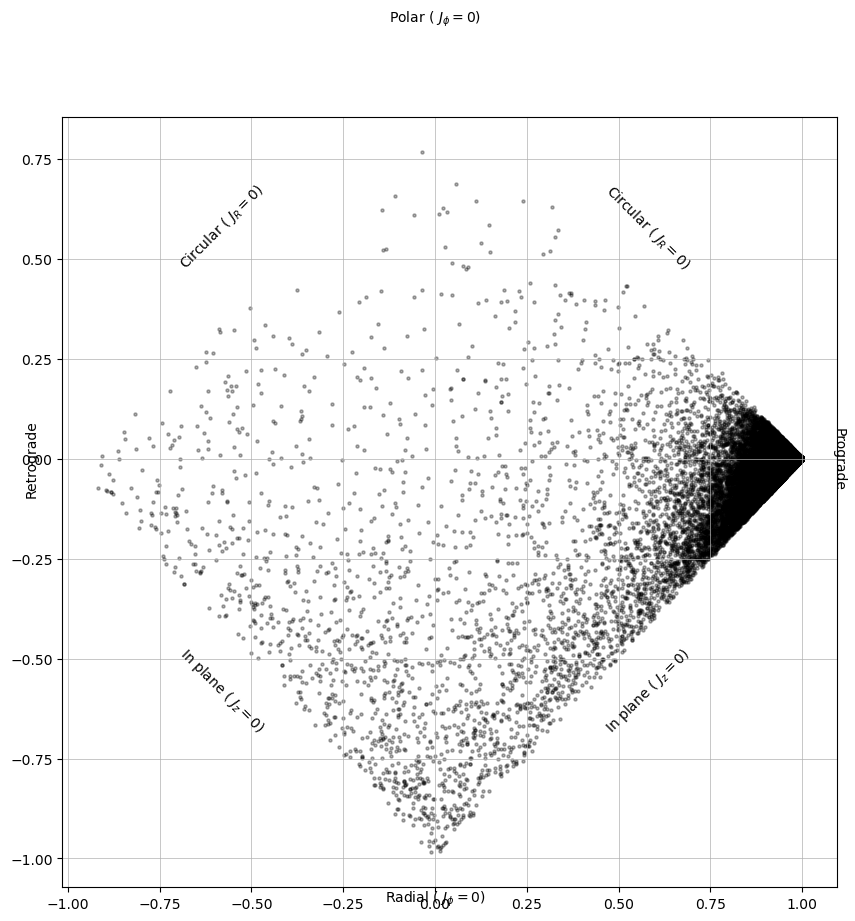

In [68]:


jzs=data[2]#dd['Jz_2']
jrs=data[1]#dd['Jr_2']
jphis=data[3]#dd['Jphi']

jtots=jzs+jrs+abs(jphis)
xvals=jphis/jtots
yvals=(jzs-jrs)/jtots

Jtotms=Jzm+Jrm+abs(Jphim)
xvalms=Jphim/Jtotms
yvalms=(Jzm-Jrm)/Jtotms
fig = plt.figure(figsize=(10,10))
#ax1 = fig.add_subplot(4,4,16)

#ax1.set_axisbelow(True)
plt.grid(visible=True, lw=0.5, zorder=-2)



plt.text(-1.1, 0, r'Retrograde', fontsize=10, color='k', fontweight='normal', rotation=90, ha='center', va='center')
plt.text(1.1, 0, r'Prograde', fontsize=10, color='k', fontweight='normal', rotation=270, ha='center', va='center')
plt.text(0, 1.1, r'Polar ( $J_{\phi} = 0$)', fontsize=10, color='k', fontweight='normal', rotation=0, ha='center', va='center')
plt.text(0, -1.1, r'Radial ( $J_{\phi} = 0$)', fontsize=10, color='k', fontweight='normal', rotation=0, ha='center', va='center')
plt.text(-0.58, 0.58, r'Circular ( $J_R = 0$)', fontsize=10, color='k', fontweight='normal', rotation=45, ha='center', va='center')
plt.text(0.58, 0.58, r'Circular ( $J_R = 0$)', fontsize=10, color='k', fontweight='normal', rotation=315, ha='center', va='center')
plt.text(0.58, -0.58, r'In plane ( $J_z = 0$)', fontsize=10, color='k', fontweight='normal', rotation=45, ha='center', va='center')
plt.text(-0.58, -0.58, r'In plane ( $J_z = 0$)', fontsize=10, color='k', fontweight='normal', rotation=315, ha='center', va='center')

#jr   = data_init.T[4]
#jphi = data_init.T[2]
jphi = pd.to_numeric(jphi)
#jz   = data_init.T[3]
jtot = np.array(jr, dtype=np.float32) + abs(np.array(jphi, dtype=np.float32)) + np.array(jz, dtype=np.float32)

plt.scatter(np.array(-jphi, dtype=np.float32)/jtot, (np.array(jz, dtype=np.float32)-np.array(jr, dtype=np.float32))/jtot,c='black', s=5, alpha=0.3, marker='o')
plt.scatter(xvalms[(clusters_id==3)],yvalms[(clusters_id==3)],s=25,c='r') #GSE,yvalms, c=labelm)
plt.scatter(xvalms[(clusters_id==2)],yvalms[(clusters_id==2)],s=25,c='c') #GSE,yvalms, c=labelm)
plt.scatter(xvalms[(clusters_id==1)],yvalms[(clusters_id==1)],s=25,c='g') #GSE,yvalms, c=labelm)
plt.scatter(xvalms[(clusters_id==5)],yvalms[(clusters_id==5)],s=25,c='y') #GSE,yvalms, c=labelm)
#plt.scatter(xvalms1,yvalms1,s=100,marker='*',c='blue')

#plt.savefig('diamond plot.jpg')

# Accuracy check

In [55]:
delta_Jr = pd.to_numeric(jr)-data1['Jr_2']
per_Jr = (delta_Jr/pd.to_numeric(jr))

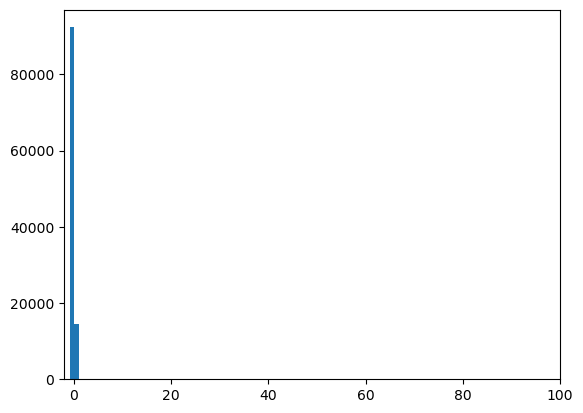

In [59]:
plt.hist(per_Jr)
plt.xlim(-2,100)
plt.show()

/tmp/ipykernel_9765/3880444529.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


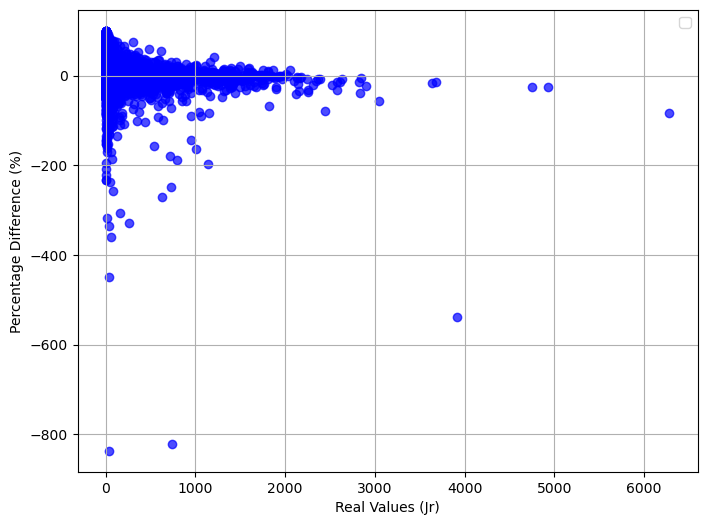

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: Assuming `data1` and `jr` are already defined in your code
# Replace `data1['Jr_2']` with your actual ground truth column and `jr` with your predictions

# Calculate the difference
delta_Jr = pd.to_numeric(jr) - data1['Jr_2']

# Calculate the percentage difference
per_Jr = (delta_Jr / pd.to_numeric(jr)) * 100

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(data1['Jr_2'],per_Jr, color='blue', alpha=0.7)

# Customize the plot
plt.xlabel('Real Values (Jr)')
plt.ylabel('Percentage Difference (%)')
#plt.ylim(0, 100)  # Optional: Adjust based on your data range
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [13]:
len(per_Jr)

106900

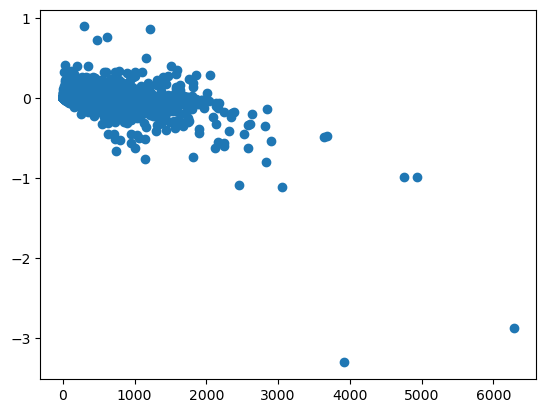

In [23]:
plt.scatter(data1['Jr_2'],delta_Jr/10**3)
#plt.xlim(0,3000)
#plt.ylim(-1,1)
plt.show()

/tmp/ipykernel_9765/2818233860.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_9765/2818233860.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_9765/2818233860.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


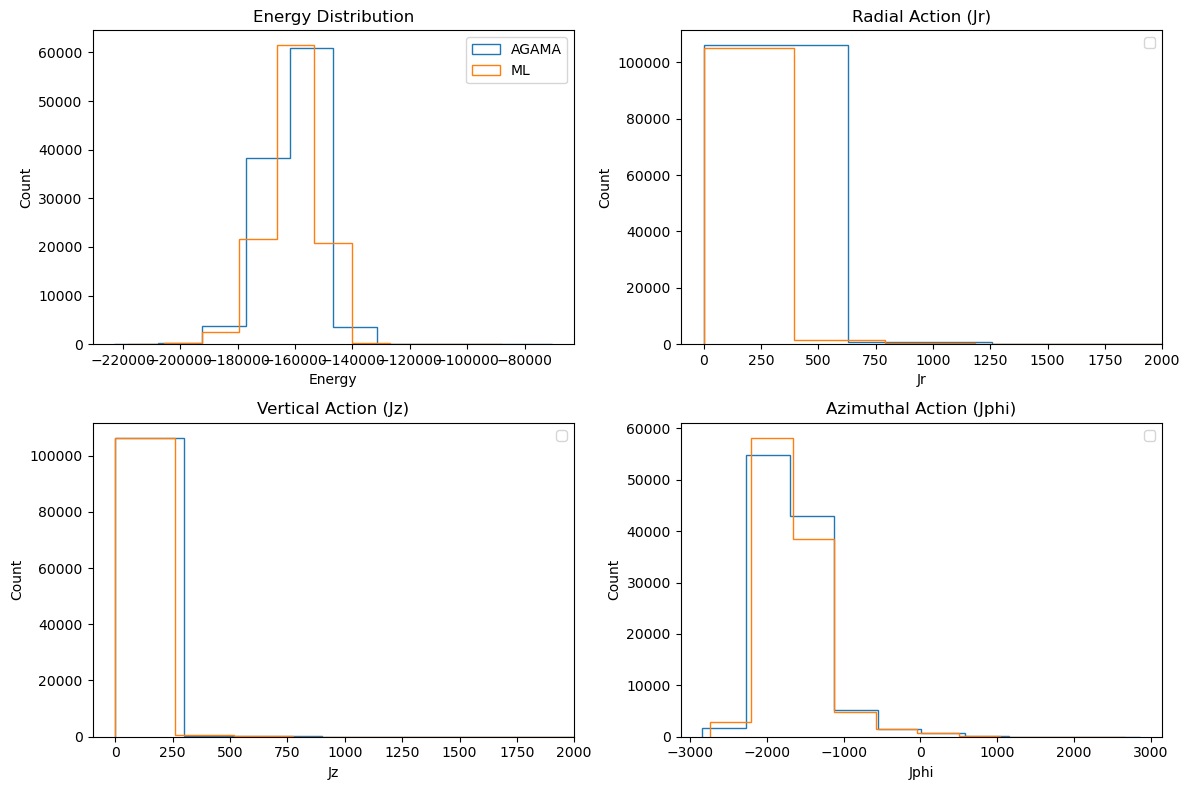

In [53]:
import matplotlib.pyplot as plt

# Assuming data1 and energy, jr, jz, jphi are already defined
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # Create a 2x2 grid of subplots

# Subplot 1: Energy Histogram
ax1 = axes[0, 0]  # Top-left plot
E2 = data1['E_2']
ax1.hist(E2[E2 < 0], histtype='step', label='AGAMA')
ax1.hist(energy, histtype='step', label='ML')
ax1.set_title('Energy Distribution')
ax1.set_xlabel('Energy')
ax1.set_ylabel('Count')
ax1.legend()

# Subplot 2: Jr Histogram
ax2 = axes[0, 1]  # Top-right plot
Jr = data1['Jr_2']
ax2.hist(Jr, histtype='step')
ax2.hist(jr, histtype='step')
ax2.set_title('Radial Action (Jr)')
ax2.set_xlabel('Jr')
ax2.set_ylabel('Count')
ax2.set_xlim(-100, 2000)
ax2.legend()

# Subplot 3: Jz Histogram
ax3 = axes[1, 0]  # Bottom-left plot
Jz = data1['Jz_2']
ax3.hist(Jz, histtype='step')
ax3.hist(jz, histtype='step')
ax3.set_title('Vertical Action (Jz)')
ax3.set_xlabel('Jz')
ax3.set_ylabel('Count')
ax3.set_xlim(-100,2000)
ax3.legend()

# Subplot 4: Jphi Histogram
ax4 = axes[1, 1]  # Bottom-right plot
Jphi = data1['Jphi']
ax4.hist(Jphi, histtype='step')
ax4.hist(jphi, histtype='step')
ax4.set_title('Azimuthal Action (Jphi)')
ax4.set_xlabel('Jphi')
ax4.set_ylabel('Count')
ax4.legend()

# Adjust layout to prevent overlap
plt.tight_layout()
#plt.savefig("ML dist.jpeg", dpi=500)
# Show the plots
plt.show()


In [31]:
# importing libraries
import seaborn as sns
import matplotlib.pyplot as plt

# importing iris dataset from the library
df2 = E2[E2 < 0]

# plotting histogram and density plot for 
# petal length using distplot() by setting color
sns.distplot(a=df2, color='green',histtype='step',
             hist_kws={"edgecolor": 'black'})

sns.distplot(a=energy, color='red', histtype='step',
             hist_kws={"edgecolor": 'black'})

# visualizing plot using matplotlib.pyplot library
plt.show()


TypeError: distplot() got an unexpected keyword argument 'histtype'

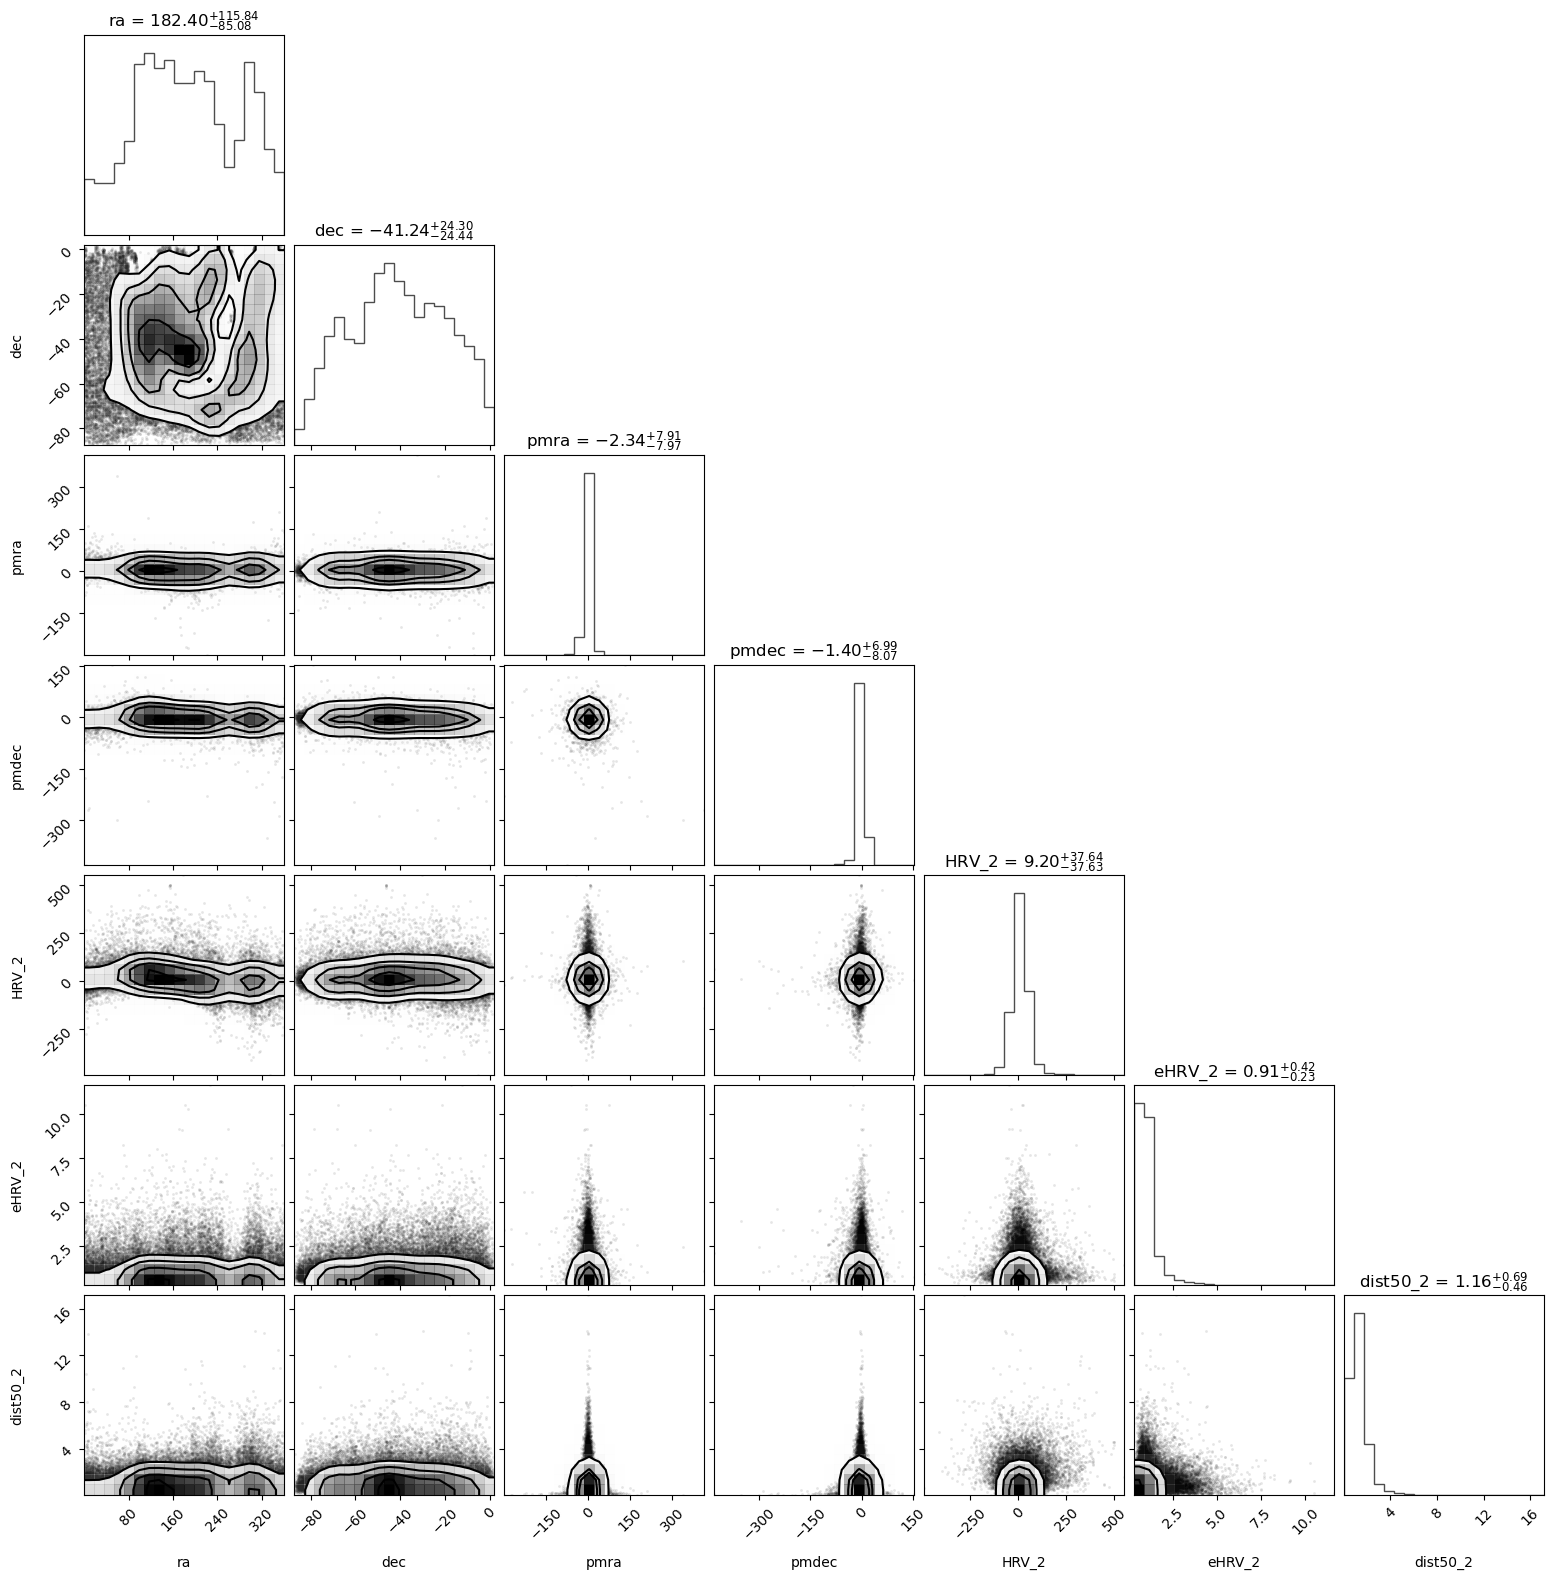

In [35]:
import pandas as pd
import corner
import matplotlib.pyplot as plt

# Assuming you have a DataFrame called data1
# Select the relevant columns
data_subset = data1[['ra', 'dec', 'pmra', 'pmdec', 'HRV_2', 'eHRV_2', 'dist50_2']]

# Create the corner plot
fig = corner.corner(data_subset, labels=['ra', 'dec', 'pmra', 'pmdec', 'HRV_2', 'eHRV_2', 'dist50_2'], 
                    show_titles=True, title_args={"fontsize": 12}, 
                    hist_kwargs={"density": True, "alpha": 0.7}, 
                    smooth=True)

# Show the plot
#plt.savefig(")
plt.show()


In [39]:
x=pd.to_numeric(data1['x'],errors='coerce')
x

0        -7.316188
1        -7.687852
2        -7.799108
3        -6.769755
4        -7.825166
            ...   
106895   -7.478475
106896   -7.578376
106897   -7.457785
106898   -7.904620
106899   -7.928279
Name: x, Length: 106900, dtype: float64

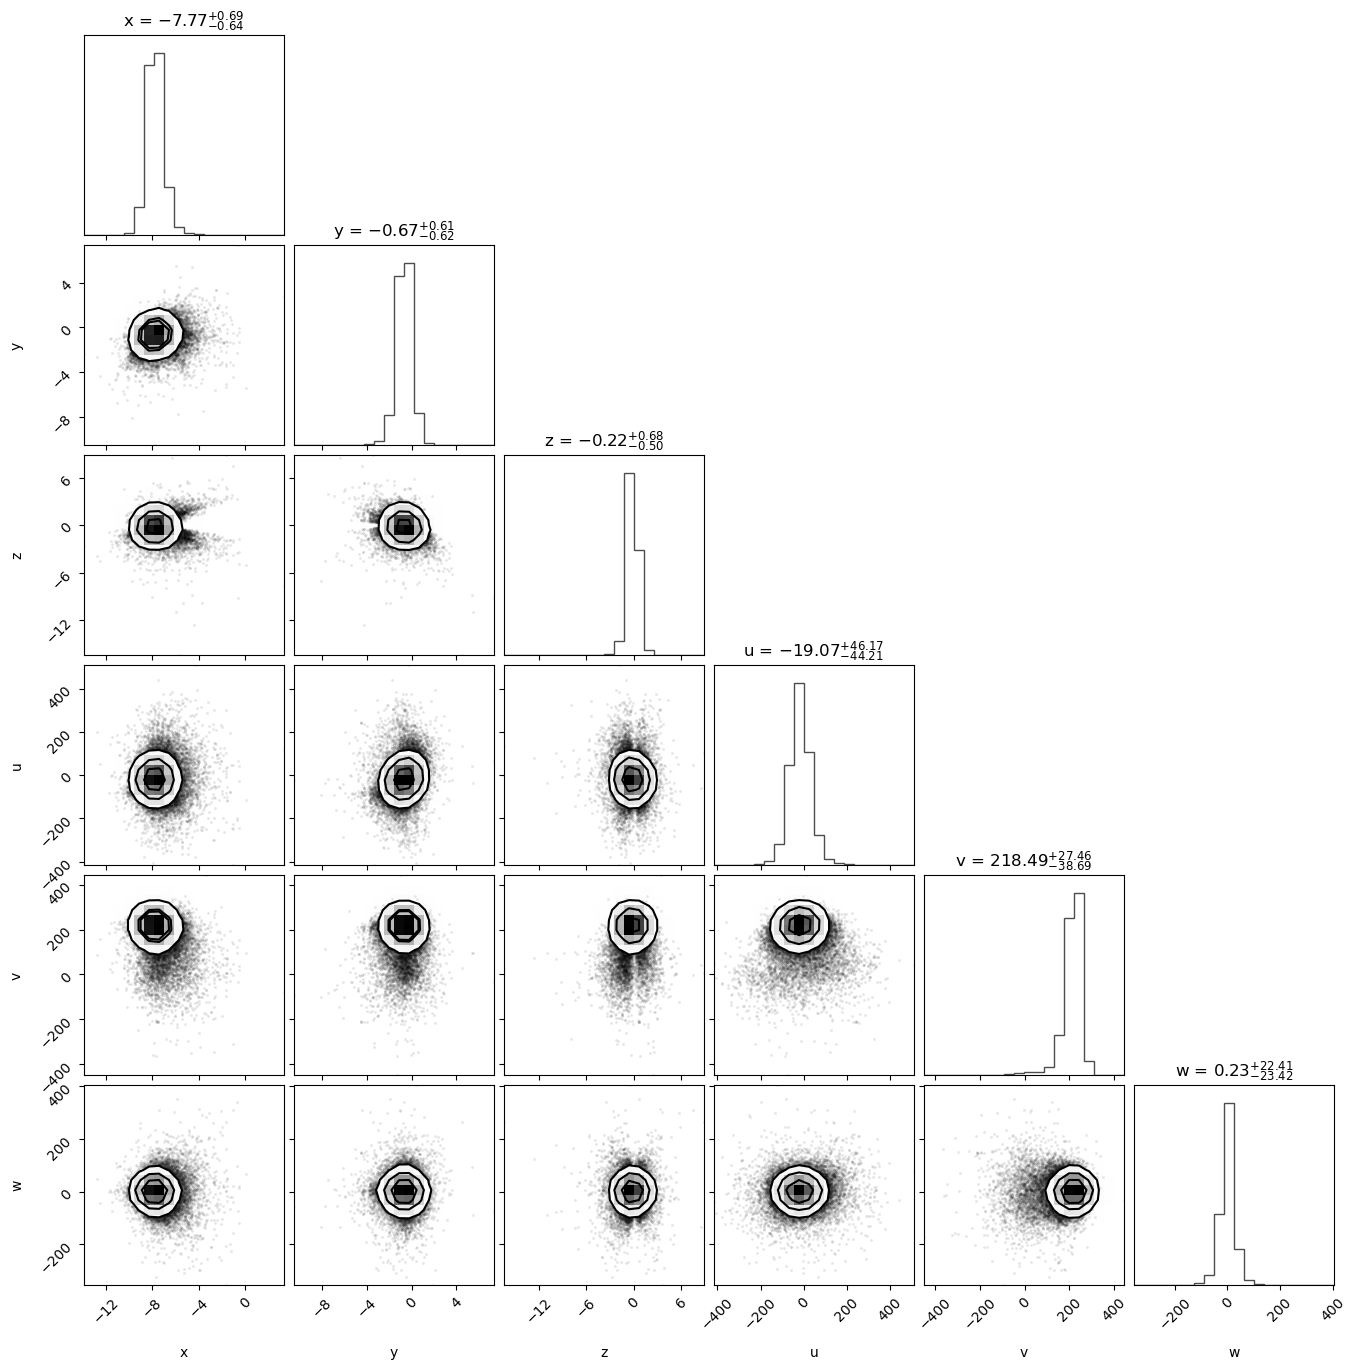

In [152]:
import pandas as pd
import numpy as np
import corner
import matplotlib.pyplot as plt

# Assuming 'data1' is your original DataFrame
# Select the relevant columns
data_subset = data1[['x', 'y', 'z', 'u_2', 'v_2', 'w_2']]

# Ensure that all values are numeric, converting non-numeric values to NaN
data_subset = data_subset.apply(pd.to_numeric, errors='coerce')

# Remove rows containing NaN or Inf values
data_subset = data_subset.replace([np.inf, -np.inf], np.nan).dropna()

# Now, create the corner plot
fig = corner.corner(data_subset, 
                    labels=['x', 'y', 'z', 'u', 'v', 'w'], 
                    show_titles=True, title_args={"fontsize": 12}, 
                    hist_kwargs={"density": True, "alpha": 0.7}, 
                    smooth=True)

# Show the plot
plt.show()


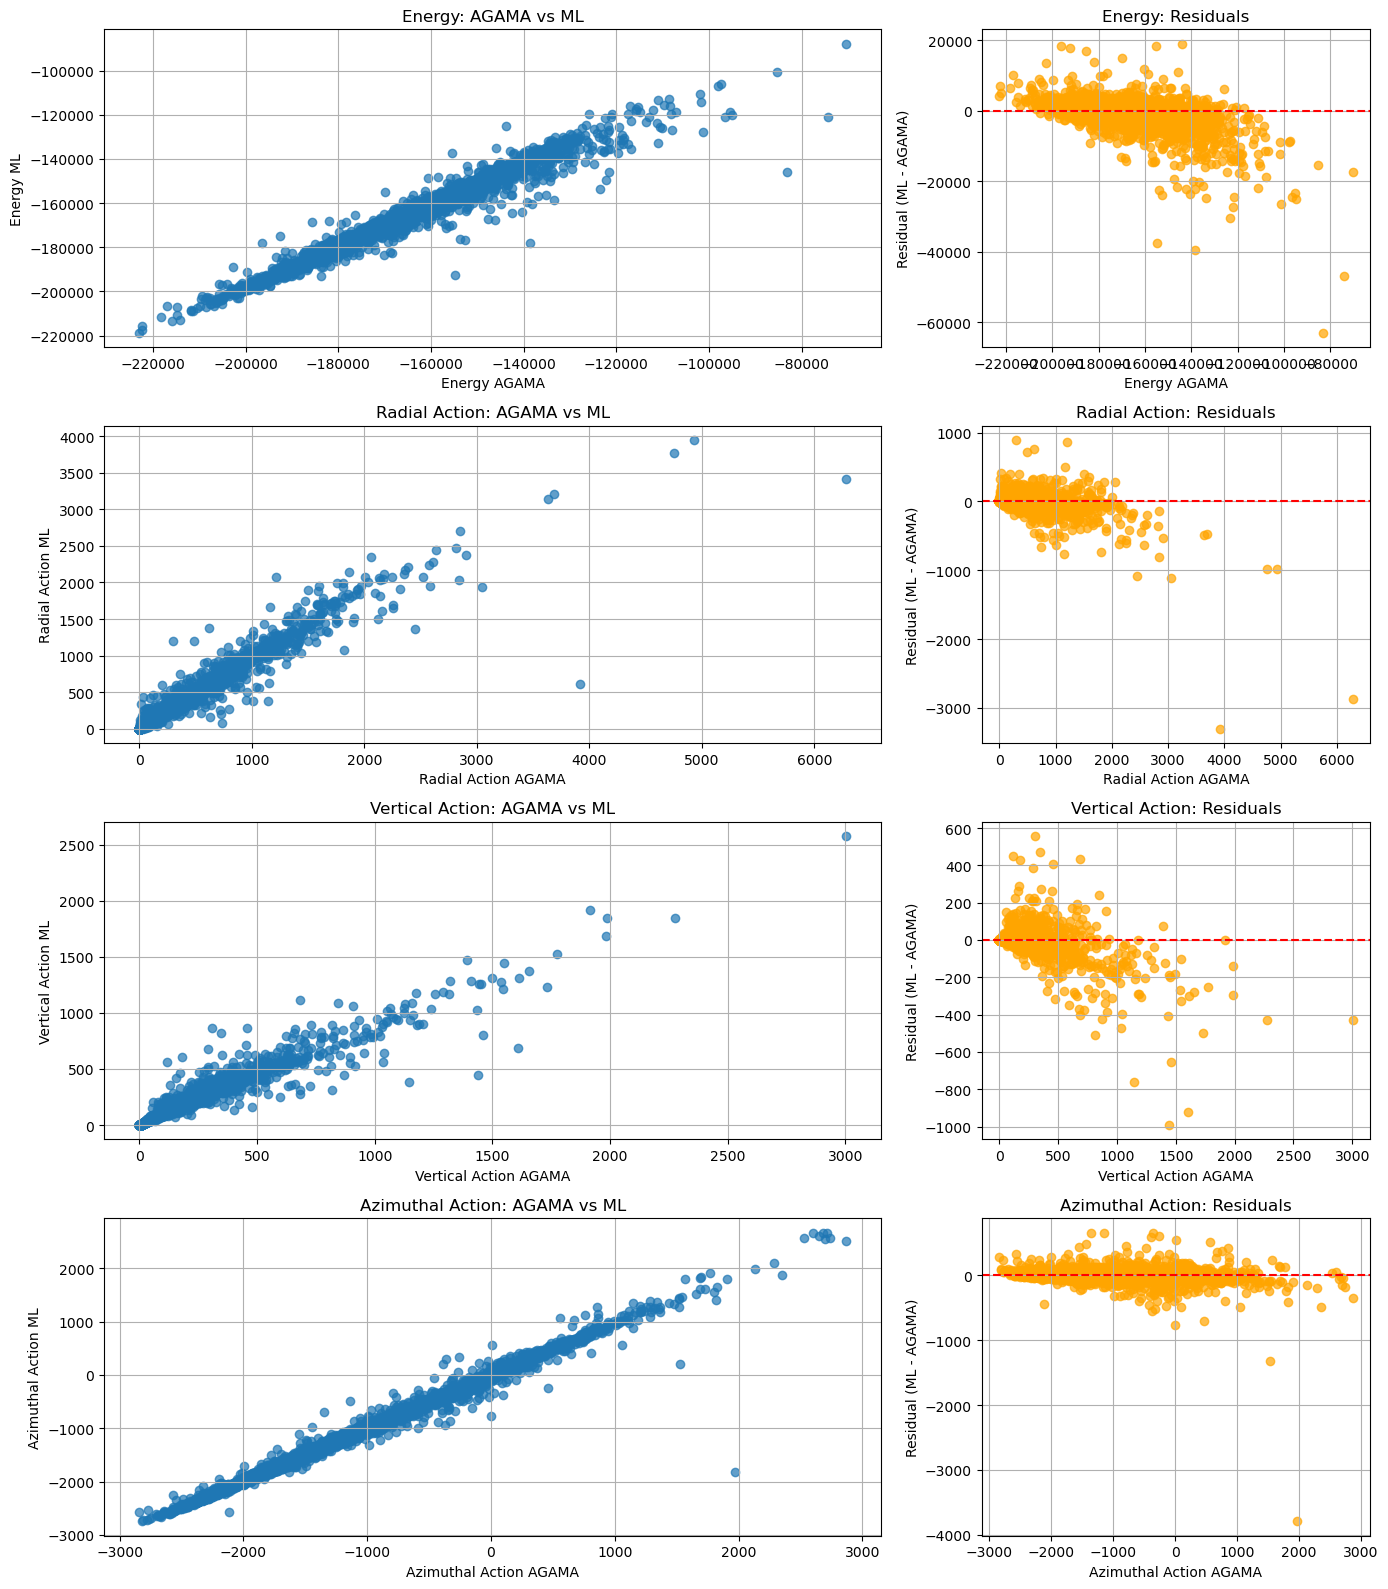

In [114]:
import matplotlib.pyplot as plt

# Combine data into a dictionary for easier iteration
data_pairs = {
    'Energy': (data1['E_2'], energy),
    'Radial Action': (data1['Jr_2'], jr),
    'Vertical Action': (data1['Jz_2'], jz),
    'Azimuthal Action': (data1['Jphi'], jphi)
}

# Create a 4x2 subplot layout
fig, axes = plt.subplots(len(data_pairs), 2, figsize=(14, 16), gridspec_kw={'width_ratios': [2, 1]})

# Iterate over data_pairs and plot scatter and residuals
for i, (label, (agama_data, ml_data)) in enumerate(data_pairs.items()):
    # Scatter plot (Left column)
    scatter_ax = axes[i, 0]
    scatter_ax.scatter(agama_data, ml_data, alpha=0.7)
    scatter_ax.set_title(f'{label}: AGAMA vs ML')
    scatter_ax.set_xlabel(f'{label} AGAMA')
    scatter_ax.set_ylabel(f'{label} ML')
    scatter_ax.grid(True)

    # Residual plot (Right column)
    residual_ax = axes[i, 1]
    residuals = ml_data - agama_data
    residual_ax.scatter(agama_data, residuals, alpha=0.7, color='orange')
    residual_ax.axhline(0, color='red', linestyle='--')  # Add a horizontal line at zero
    residual_ax.set_title(f'{label}: Residuals')
    residual_ax.set_xlabel(f'{label} AGAMA')
    residual_ax.set_ylabel('Residual (ML - AGAMA)')
    residual_ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


            E2_AGAMA     E2_ML  Jr_AGAMA     Jr_ML  Jz_AGAMA     Jz_ML  \
E2_AGAMA    1.000000  0.995642 -0.080099 -0.104267 -0.122113 -0.134940   
E2_ML       0.995642  1.000000 -0.105873 -0.123670 -0.166197 -0.178677   
Jr_AGAMA   -0.080099 -0.105873  1.000000  0.983591  0.403131  0.427791   
Jr_ML      -0.104267 -0.123670  0.983591  1.000000  0.424351  0.441992   
Jz_AGAMA   -0.122113 -0.166197  0.403131  0.424351  1.000000  0.979512   
Jz_ML      -0.134940 -0.178677  0.427791  0.441992  0.979512  1.000000   
Jphi_AGAMA -0.782069 -0.800043  0.596265  0.621400  0.467749  0.491590   
Jphi_ML    -0.783327 -0.801205  0.595323  0.621218  0.468140  0.491936   

            Jphi_AGAMA   Jphi_ML  
E2_AGAMA     -0.782069 -0.783327  
E2_ML        -0.800043 -0.801205  
Jr_AGAMA      0.596265  0.595323  
Jr_ML         0.621400  0.621218  
Jz_AGAMA      0.467749  0.468140  
Jz_ML         0.491590  0.491936  
Jphi_AGAMA    1.000000  0.998675  
Jphi_ML       0.998675  1.000000  


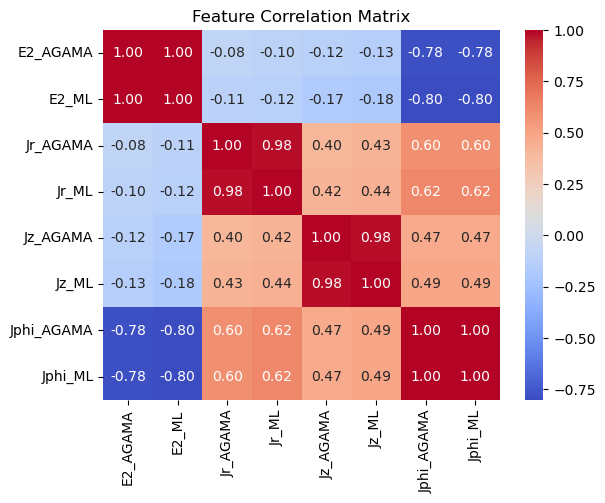

In [166]:
correlation_matrix = df.corr()
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


In [110]:
import pandas as pd
import numpy as np
import corner
import matplotlib.pyplot as plt

# Assuming 'data1' is your original DataFrame
# Select the relevant columns
data_subset = [data1[['x', 'y', 'z', 'u_2', 'v_2', 'w_2']],jr]

# Ensure that all values are numeric, converting non-numeric values to NaN
data_subset = data_subset.apply(pd.to_numeric, errors='coerce')

# Remove rows containing NaN or Inf values
data_subset = data_subset.replace([np.inf, -np.inf], np.nan).dropna()

# Now, create the corner plot
fig = corner.corner(data_subset, 
                    labels=['x', 'y', 'z', 'u', 'v', 'w','jr'], 
                    show_titles=True, title_args={"fontsize": 12}, 
                    hist_kwargs={"density": True, "alpha": 0.7}, 
                    smooth=True)

# Show the plot
plt.show()


AttributeError: 'list' object has no attribute 'apply'